# Generate Stable LaTeX Tables for Model Comparison

This notebook converts saved model outputs and paper metadata into the publication-ready tables used by `overleaf/paper.tex`.

The workflow is intentionally reproducible:

1. `3Compare_model.ipynb` and `4Pricing_Test.ipynb` compute timestamped Parquet results.
2. `timestamp` below selects the source result bundle.
3. This notebook writes the paper's table fragments with stable, version-free filenames.
4. `paper.tex` inputs those stable filenames, so rerunning this notebook updates the paper without changing any LaTeX paths.
5. The final cell compiles all generated tables in one validation PDF.

The selected source timestamp is retained only inside this notebook for provenance. It is never written into a public table filename, caption, label, or note.

## 1. Setup

Change only `timestamp` when a different model-comparison run becomes the paper version. Then run all cells. The generated `.tex` filenames remain unchanged.

In [1]:
from pathlib import Path
import shutil
import subprocess
import re

import numpy as np
import pandas as pd
from scipy.stats import norm
from IPython.display import display, Markdown

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 180)
pd.set_option("display.max_rows", 100)

PROJECT_ROOT = Path("/Users/jianbinchen/NonSync/GitHub/Research/PricingTailRisk_MDN")

timestamp = "20260928_0204" 
robustness_timestamp = "20260925_0018"

RESULT_DIR = PROJECT_ROOT / "output"
TEX_DIR = PROJECT_ROOT / "overleaf/tab_tex"
TEX_DIR.mkdir(parents=True, exist_ok=True)

MODEL_ORDER = [
    "rolling_normal",
    "linear_quantile",
    "fused_normal_k1",
    "fused_normal_k3",
    "structured_normal_k3",
]

MODEL_LABELS = {
    "rolling_normal": "Rolling Normal",
    "linear_quantile": "Linear Quantile",
    "fused_normal_k1": "Fused Normal K1",
    "fused_normal_k3": "Fused Normal K3",
    "structured_normal_k3": "Structured Normal K3",
}

METRIC_LABELS = {
    "nll": "NLL",
    "crps": "CRPS",
    "tail_crps_5": "Tail CRPS (5%)",
    "tail_crps_10": "Tail CRPS (10%)",
    # "qs_1": "QS (1%)",
    "qs_5": "QS (5%)",
    "qs_10": "QS (10%)",
    # "fz0_1": "FZ0 (1%)",
    "fz0_5": "FZ0 (5%)",
    "fz0_10": "FZ0 (10%)",
}

print("Project root:", PROJECT_ROOT)
print("Result timestamp:", timestamp)
print("LaTeX output folder:", TEX_DIR)

Project root: /Users/jianbinchen/NonSync/GitHub/Research/PricingTailRisk_MDN
Result timestamp: 20260928_0204
LaTeX output folder: /Users/jianbinchen/NonSync/GitHub/Research/PricingTailRisk_MDN/overleaf/tab_tex


## 2. Reusable LaTeX Exporter

All tables use the same rules:

- one independent `.tex` file per table;
- English captions and notes for direct use in the paper;
- `booktabs`, `threeparttable`, and `adjustbox` formatting;
- `--` for missing values;
- a landscape wrapper only for genuinely wide tables.

The DataFrame shown in the notebook is the same formatted table written to LaTeX.


In [2]:
# EXPORT_MANIFEST = []

def format_table(frame, formats=None, default_float=".4f"):
    """Return a string-valued table with stable publication formatting."""
    formats = formats or {}
    formatted = frame.copy()

    for column in formatted.columns:
        formatter = formats.get(column)

        def format_value(value):
            if pd.isna(value):
                return "--"
            if formatter is not None:
                if callable(formatter):
                    return str(formatter(value))
                return format(value, formatter)
            if isinstance(value, (float, np.floating)):
                return format(value, default_float)
            if isinstance(value, (int, np.integer)):
                return str(int(value))
            if isinstance(value, (pd.Timestamp, np.datetime64)):
                return pd.Timestamp(value).strftime("%Y-%m")
            return str(value)

        formatted[column] = formatted[column].map(format_value)

    return formatted


def export_latex_table(
    frame,
    filename,
    caption,
    label,
    note,
    formats=None,
    landscape=False,
    font_size="small",
    column_format=None,
    table_position=None,
    arraystretch=None,
    use_adjustbox=True,
):
    """Display one table and write one self-contained LaTeX table file."""
    # Make appendix labels unique and retain input-transformation metadata.
    baseline_tables = {
        "02_fz0_domain.tex", "03_forecast_performance_summary.tex",
        "03_forecast_performance_summary_compact.tex",
        "06_structured_normal_k3_pairwise_tests.tex", "08_pit_summary.tex",
        "09_var_coverage_tests_wide.tex", "11_component_label_map.tex",
        "structure_effective_table.tex", "structure_decomposition_table.tex",
        "factor_coefficients_k3_ew.tex", "fmb_summary_transposed.tex",
        "17_adverse_state_pricing.tex",
    }
    if filename.endswith("_robustness.tex"):
        caption += ": Rank-Standardized Inputs"
        if not label.endswith("_robustness"):
            label += "_robustness"
        note = (
            r"Forecasts use monthly cross-sectional rank-standardized firm predictors. "
            r"This transformation applies to model inputs, not to pricing signals or controls. "
            + note
        )
    elif filename in baseline_tables:
        note = (
            r"Forecasts use normal-standardized firm predictors (monthly cross-sectional z-scores). "
            + note
        )

    public_metadata = " ".join([filename, caption, label, note])
    if re.search(r"\b\d{8}_\d{4}\b", public_metadata):
        raise ValueError("Generated table metadata must not contain a timestamp or version tag.")
    formatted = format_table(frame, formats=formats)
    if column_format is None:
        column_format = "l" + "r" * max(len(formatted.columns) - 1, 0)
    tabular = formatted.to_latex(
        index=False,
        escape=True,
        column_format=column_format,
    ).strip()

    if table_position is None:
        table_position = "p" if landscape else "!htbp"

    table_body = tabular
    if arraystretch is not None:
        table_body = f"\\renewcommand{{\\arraystretch}}{{{arraystretch}}}\n{table_body}"
    if use_adjustbox:
        table_body = (
            "\\begin{adjustbox}{max width=\\linewidth}\n"
            + table_body
            + "\n\\end{adjustbox}"
        )

    table_text = f"""\\begin{{table}}[{table_position}]
                    \\centering
                    \\caption{{{caption}}}
                    \\label{{{label}}}
                    \\{font_size}
                    {table_body}
                    \\vspace{{0.25em}}

                    \\begin{{minipage}}{{0.98\\linewidth}}
                    \\footnotesize \\textit{{Notes:}} {note}
                    \\end{{minipage}}
                    \\end{{table}}
                    """
    if landscape:
        table_text = "\\begin{landscape}\n" + table_text + "\\end{landscape}\n"

    output_path = TEX_DIR / filename
    output_path.write_text(table_text, encoding="utf-8")

    # EXPORT_MANIFEST.append(
    #     {
    #         "File": filename,
    #         "Caption": caption,
    #         "Label": label,
    #         "Rows": len(formatted),
    #         "Columns": len(formatted.columns),
    #         "Landscape": landscape,
    #     }
    # )

    # display(formatted)
    print("Saved:", output_path.relative_to(PROJECT_ROOT))
    return formatted

# Paper Tables

Each section below creates exactly one `.tex` file. The section text explains what the table is for and how to read it.


## Descriptive Tables Used Directly by the Paper

These two tables document the model designs and the firm-predictor groups. They contain no estimated results, but generating them here keeps their captions, labels, and notes synchronized with the paper.


In [3]:
model_summary_table = pd.DataFrame({
    "Model": [
        "Rolling Normal",
        "Linear Quantile",
        "Fused Normal K1",
        "Fused Normal K3",
        "Structured Normal K3",
    ],
    "Information": [
        "Own return history",
        "Macro, firm, FF12",
        "Macro, firm, FF12",
        "Macro, firm, FF12",
        "Macro, firm, FF12",
    ],
    "Distribution output": [
        "One Normal",
        "27 quantiles",
        "One conditional Normal",
        "Three-Normal mixture",
        "Three-Normal mixture",
    ],
    "Weights": [
        "Not applicable",
        "Not applicable",
        "One",
        "Firm-month specific",
        "Common within month",
    ],
    "Means and scales": [
        "Rolling estimates",
        "Not applicable",
        "Firm-month specific",
        "Firm-month specific",
        "Firm-month specific",
    ],
})

export_latex_table(
    model_summary_table,
    "tab_model_summary.tex",
    "Summary of the Five Forecast Models",
    "tab:model_summary",
    r"K denotes the number of Normal mixture components. The three neural models use the same macroeconomic, firm-level, and FF12 industry information. In Structured Normal K3, mixture weights are common across firms within a month, while component means and scales remain firm-month specific.",
    font_size="small",
    column_format=r">{\raggedright\arraybackslash}p{0.16\textwidth}>{\raggedright\arraybackslash}p{0.15\textwidth}>{\raggedright\arraybackslash}p{0.19\textwidth}>{\raggedright\arraybackslash}p{0.18\textwidth}>{\raggedright\arraybackslash}p{0.18\textwidth}",
    arraystretch=1.08,
    use_adjustbox=False,
)


Saved: overleaf/tab_tex/tab_model_summary.tex


,Model,Information,Distribution output,Weights,Means and scales
0,Rolling Normal,Own return history,One Normal,Not applicable,Rolling estimates
1,Linear Quantile,"Macro, firm, FF12",27 quantiles,Not applicable,Not applicable
2,Fused Normal K1,"Macro, firm, FF12",One conditional Normal,One,Firm-month specific
3,Fused Normal K3,"Macro, firm, FF12",Three-Normal mixture,Firm-month specific,Firm-month specific
4,Structured Normal K3,"Macro, firm, FF12",Three-Normal mixture,Common within month,Firm-month specific


In [4]:
firm_predictor_groups = pd.DataFrame({
    "Group": [
        "Recent market information",
        "Valuation",
        "Profitability and efficiency",
        "Leverage and liquidity",
        "Investment and accounting quality",
    ],
    "Variables": [
        "Current return, price, 12-month momentum, rolling mean return, rolling return volatility, turnover, and log market capitalization.",
        "Book-to-market, enterprise-value multiple, price-to-sales, and price-to-cash-flow.",
        "Operating profit margin after depreciation, cash-flow margin, return on equity, gross profitability, and asset turnover.",
        "Debt-to-assets, short-term debt share, cash ratio, and current ratio.",
        "R&D-to-sales and accruals.",
    ],
})

export_latex_table(
    firm_predictor_groups,
    "tab_firm_predictors.tex",
    "Firm-Level Predictors",
    "tab:firm_predictors",
    r"Appendix \ref{app:data} lists the exact variable names, definitions, and sources.",
    font_size="small",
    column_format=r">{\raggedright\arraybackslash}p{0.30\textwidth}>{\raggedright\arraybackslash}p{0.60\textwidth}",
    arraystretch=1.08,
    use_adjustbox=False,
)


Saved: overleaf/tab_tex/tab_firm_predictors.tex


,Group,Variables
0,Recent market information,"Current return, price, 12-month momentum, roll..."
1,Valuation,"Book-to-market, enterprise-value multiple, pri..."
2,Profitability and efficiency,"Operating profit margin after depreciation, ca..."
3,Leverage and liquidity,"Debt-to-assets, short-term debt share, cash ra..."
4,Investment and accounting quality,R&D-to-sales and accruals.


## Common Sample Coverage

This table shows whether the five models are compared on the same stock-month sample. It belongs in the data or forecast-evaluation section.


In [5]:
table_name = "coverage_table"
path = RESULT_DIR / f"{table_name}_{timestamp}.parquet"
sample = pd.read_parquet(path)


table = pd.DataFrame({
    "Model": sample["model_id"].astype(object).map(MODEL_LABELS),
    "Available stock-months": sample["available_rows"],
    "Months": sample["months"],
    "First month": pd.to_datetime(sample["first_month"]),
    "Last month": pd.to_datetime(sample["last_month"]),
    "Common stock-months": sample["common_rows"],
    "Common share (%)": 100 * sample["common_share"],
})

export_latex_table(
    table,
    "sample_coverage.tex",
    "Common Out-of-Sample Coverage",
    "tab:sample_coverage",
    r"Available stock-months are observations produced by each model before the common-sample restriction. Common stock-months are observations shared by all five models. The common share is common stock-months divided by available stock-months.",
    formats={
        "Available stock-months": ",.0f",
        "Months": ".0f",
        "First month": lambda x: pd.Timestamp(x).strftime("%Y-%m"),
        "Last month": lambda x: pd.Timestamp(x).strftime("%Y-%m"),
        "Common stock-months": ",.0f",
        "Common share (%)": ".2f",
    },
)

Saved: overleaf/tab_tex/sample_coverage.tex


,Model,Available stock-months,Months,First month,Last month,Common stock-months,Common share (%)
0,Rolling Normal,"480,446",216,2007-01,2024-12,"480,446",100.00
1,Linear Quantile,"480,446",216,2007-01,2024-12,"480,446",100.00
2,Fused Normal K1,"480,446",216,2007-01,2024-12,"480,446",100.00
3,Fused Normal K3,"480,446",216,2007-01,2024-12,"480,446",100.00
4,Structured Normal K3,"480,446",216,2007-01,2024-12,"480,446",100.00


## FZ0 Domain Retention

The joint FZ0 score is defined only when its VaR and ES inputs satisfy the score's domain. This table reports how much of the sample remains valid.


In [6]:
table_name = "fz_domain_table"
path = RESULT_DIR / f"{table_name}_{timestamp}.parquet"
table = pd.read_parquet(path)
valid = table.pivot(index="model_id", columns="alpha", values="model_valid_share").reindex(MODEL_ORDER)
common = table.groupby("alpha")["all_model_common_share"].first()


table_02 = pd.DataFrame({
    "Model or sample": [MODEL_LABELS[m] for m in MODEL_ORDER] + ["All-model common sample"],
    # "1% retained": list(100 * valid[0.01]) + [100 * common.loc[0.01]],
    "5% retained": list(100 * valid[0.05]) + [100 * common.loc[0.05]],
    "10% retained": list(100 * valid[0.10]) + [100 * common.loc[0.10]],
})

export_latex_table(
    table_02,
    "02_fz0_domain.tex",
    "FZ0 Domain Retention Rates",
    "tab:fz_domain",
    r"Entries are percentages of the common forecast sample. Model rows report the share satisfying that model's FZ0 domain restrictions. The final row reports the share that is jointly valid for all five models and is therefore used in model comparisons.",
    formats={
        # "1% retained": ".2f", 
             "5% retained": ".2f", "10% retained": ".2f"},
)

Saved: overleaf/tab_tex/02_fz0_domain.tex


,Model or sample,5% retained,10% retained
0,Rolling Normal,99.74,99.63
1,Linear Quantile,99.27,98.32
2,Fused Normal K1,100.00,99.75
3,Fused Normal K3,100.00,99.69
4,Structured Normal K3,100.00,100.00
5,All-model common sample,99.00,97.44


## Forecast Performance Summary

These cells export both wide and compact versions of the main forecast-comparison table. The paper uses the compact version, which places each score and its rank in the same cell.


In [7]:
table_name = "comparison_summary"
path = RESULT_DIR / f"{table_name}_{timestamp}.parquet"

summary = pd.read_parquet(path).set_index("model_id").reindex(MODEL_ORDER)

# Each tuple contains:
# (column name in the saved result, table label, number format)
metric_specs = [
    ("nll", "NLL", ".3f"),
    ("crps", "CRPS", ".6f"),
    ("tail_crps_5", "Tail CRPS (5%)", ".6f"),
    ("tail_crps_10", "Tail CRPS (10%)", ".6f"),
    ("qs_5", "QS (5%)", ".6f"),
    ("qs_10", "QS (10%)", ".6f"),
    ("fz0_5", "FZ0 (5%)", ".6f"),
    ("fz0_10", "FZ0 (10%)", ".6f"),
]

# # Check that every required score and rank exists.
# required_columns = []

# for metric, _, _ in metric_specs:
#     required_columns.extend([metric, f"rank_{metric}"])

# missing_columns = [
#     column
#     for column in required_columns
#     if column not in summary.columns
# ]

# if missing_columns:
#     raise KeyError(
#         "The comparison summary is missing these columns: "
#         + ", ".join(missing_columns)
#     )

# Build the combined table.
table_03 = pd.DataFrame({
    "Model": [MODEL_LABELS[model] for model in MODEL_ORDER]
})

formats_03 = {}

for metric, label, score_format in metric_specs:
    rank_label = f"{label} rank"

    table_03[label] = summary[metric].to_numpy()
    table_03[rank_label] = summary[f"rank_{metric}"].to_numpy()

    formats_03[label] = score_format
    formats_03[rank_label] = ".0f"

# Export one combined LaTeX table.
formatted_table_03 = export_latex_table(
    table_03,
    "03_forecast_performance_summary.tex",
    "Out-of-Sample Forecast Performance Summary",
    "tab:forecast_performance_summary",
    (
        r"The table reports equal-month averages over the common "
        r"stock-month sample. FZ0 jointly evaluates VaR and expected "
        r"shortfall at the stated probability level. Tail CRPS evaluates "
        r"the 0--5\% and 0--10\% lower tail of the predictive distribution. NLL "
        r"evaluates the full predictive density. CRPS evaluates the full "
        r"predictive distribution. QS evaluates the predicted quantiles. "
        r"Lower scores and lower ranks indicate better forecasts. "
        r"NLL is unavailable for Linear Quantile because that model does "
        r"not produce an exact continuous density."
    ),
    formats=formats_03,
    landscape=True,
    font_size="scriptsize",
)

# Clearly display the complete table inside the notebook.
display(formatted_table_03)

Saved: overleaf/tab_tex/03_forecast_performance_summary.tex


,Model,NLL,NLL rank,CRPS,CRPS rank,Tail CRPS (5%),Tail CRPS (5%) rank,Tail CRPS (10%),Tail CRPS (10%) rank,QS (5%),QS (5%) rank,QS (10%),QS (10%) rank,FZ0 (5%),FZ0 (5%) rank,FZ0 (10%),FZ0 (10%) rank
0,Rolling Normal,61486.849,4,0.075154,2,0.019054,5,0.029743,4,0.031244,4,0.048734,2,-1.207900,2,-1.488884,2
1,Linear Quantile,--,--,0.083491,5,0.017349,2,0.030373,5,0.031732,5,0.053903,5,-1.192204,3,-1.415731,3
2,Fused Normal K1,-0.475,3,0.078382,4,0.017527,3,0.029146,2,0.030576,2,0.050084,3,-1.181101,4,-1.392088,4
3,Fused Normal K3,-0.550,2,0.077718,3,0.017951,4,0.029582,3,0.031200,3,0.050303,4,-1.148774,5,-1.359170,5
4,Structured Normal K3,-0.644,1,0.073226,1,0.016674,1,0.027421,1,0.028822,1,0.046696,1,-1.268839,1,-1.493909,1


In [8]:
table_name = "comparison_summary"
path = RESULT_DIR / f"{table_name}_{timestamp}.parquet"

summary = pd.read_parquet(path).set_index("model_id").reindex(MODEL_ORDER)

# Each tuple contains:
# (column name in the saved result, table label, number format)
metric_specs = [
    ("nll", "NLL", ".4f"),
    ("crps", "CRPS", ".4f"),
    ("tail_crps_5", "Tail CRPS (5%)", ".4f"),
    ("tail_crps_10", "Tail CRPS (10%)", ".4f"),
    ("qs_5", "QS (5%)", ".4f"),
    ("qs_10", "QS (10%)", ".4f"),
    ("fz0_5", "FZ0 (5%)", ".4f"),
    ("fz0_10", "FZ0 (10%)", ".4f"),
]


# 构建紧凑版表格：数值和排名放同一个单元格，例如 61486.849 (5)
table_compact = pd.DataFrame({
    "Model": [MODEL_LABELS[model] for model in MODEL_ORDER]
})

for metric, label, score_format in metric_specs:
    combined_col = []
    # 遍历数值和排名，拼装成字符串
    for score, rank in zip(summary[metric], summary[f"rank_{metric}"]):
        if pd.isna(score): # 处理 Linear Quantile 的 NLL 缺失值
            combined_col.append("--")
        else:
            combined_col.append(f"{score:{score_format}} ({int(rank)})")
            
    table_compact[label] = combined_col

# 导出LaTeX（注意：内容已经格式化为字符串，所以不需要传 formats 字典，直接去掉 landscape=True）
formatted_table_compact = export_latex_table(
    table_compact,
    "03_forecast_performance_summary_compact.tex",
    "Out-of-Sample Forecast Performance Summary",
    "tab:forecast_performance_summary",
    (
        r"The table reports equal-month averages over the common stock-month sample. "
        r"Numbers in parentheses are model ranks, not predictor ranks. "  # 补充一句括号代表排名的说明
        r"Lower scores and lower ranks indicate better forecasts. "
        r"NLL evaluates predictive density; CRPS evaluates the full distribution; "
        r"tail CRPS averages quantile loss over the 0--5\% or 0--10\% region; "
        r"QS evaluates the stated quantile; FZ0 evaluates VaR and ES jointly "
        r"on the all-model valid sample. NLL is unavailable for Linear Quantile."
    ),
    landscape=False, # 可以安心用竖版了！
    font_size="small",
)

display(table_compact)

Saved: overleaf/tab_tex/03_forecast_performance_summary_compact.tex


,Model,NLL,CRPS,Tail CRPS (5%),Tail CRPS (10%),QS (5%),QS (10%),FZ0 (5%),FZ0 (10%)
0,Rolling Normal,61486.8486 (4),0.0752 (2),0.0191 (5),0.0297 (4),0.0312 (4),0.0487 (2),-1.2079 (2),-1.4889 (2)
1,Linear Quantile,--,0.0835 (5),0.0173 (2),0.0304 (5),0.0317 (5),0.0539 (5),-1.1922 (3),-1.4157 (3)
2,Fused Normal K1,-0.4748 (3),0.0784 (4),0.0175 (3),0.0291 (2),0.0306 (2),0.0501 (3),-1.1811 (4),-1.3921 (4)
3,Fused Normal K3,-0.5504 (2),0.0777 (3),0.0180 (4),0.0296 (3),0.0312 (3),0.0503 (4),-1.1488 (5),-1.3592 (5)
4,Structured Normal K3,-0.6438 (1),0.0732 (1),0.0167 (1),0.0274 (1),0.0288 (1),0.0467 (1),-1.2688 (1),-1.4939 (1)


In [9]:
# robustness results
table_name = "comparison_summary"
path = RESULT_DIR / f"{table_name}_{robustness_timestamp}.parquet"

summary = pd.read_parquet(path).set_index("model_id").reindex(MODEL_ORDER)

# Each tuple contains:
# (column name in the saved result, table label, number format)
metric_specs = [
    ("nll", "NLL", ".4f"),
    ("crps", "CRPS", ".4f"),
    ("tail_crps_5", "Tail CRPS (5%)", ".4f"),
    ("tail_crps_10", "Tail CRPS (10%)", ".4f"),
    ("qs_5", "QS (5%)", ".4f"),
    ("qs_10", "QS (10%)", ".4f"),
    ("fz0_5", "FZ0 (5%)", ".4f"),
    ("fz0_10", "FZ0 (10%)", ".4f"),
]


# 构建紧凑版表格：数值和排名放同一个单元格，例如 61486.849 (5)
table_compact = pd.DataFrame({
    "Model": [MODEL_LABELS[model] for model in MODEL_ORDER]
})

for metric, label, score_format in metric_specs:
    combined_col = []
    # 遍历数值和排名，拼装成字符串
    for score, rank in zip(summary[metric], summary[f"rank_{metric}"]):
        if pd.isna(score): # 处理 Linear Quantile 的 NLL 缺失值
            combined_col.append("--")
        else:
            combined_col.append(f"{score:{score_format}} ({int(rank)})")
            
    table_compact[label] = combined_col

# 导出LaTeX（注意：内容已经格式化为字符串，所以不需要传 formats 字典，直接去掉 landscape=True）
formatted_table_compact = export_latex_table(
    table_compact,
    "03_forecast_performance_summary_compact_robustness.tex",
    "Out-of-Sample Forecast Performance Summary",
    "tab:forecast_performance_summary",
    (
        r"The table reports equal-month averages over the common stock-month sample. "
        r"Numbers in parentheses are model ranks, not predictor ranks. "  # 补充一句括号代表排名的说明
        r"Lower scores and lower ranks indicate better forecasts. "
        r"NLL evaluates predictive density; CRPS evaluates the full distribution; "
        r"tail CRPS averages quantile loss over the 0--5\% or 0--10\% region; "
        r"QS evaluates the stated quantile; FZ0 evaluates VaR and ES jointly "
        r"on the all-model valid sample. NLL is unavailable for Linear Quantile."
    ),
    landscape=False, # 可以安心用竖版了！
    font_size="small",
)

display(table_compact)

Saved: overleaf/tab_tex/03_forecast_performance_summary_compact_robustness.tex


,Model,NLL,CRPS,Tail CRPS (5%),Tail CRPS (10%),QS (5%),QS (10%),FZ0 (5%),FZ0 (10%)
0,Rolling Normal,61486.8486 (4),0.0752 (2),0.0191 (5),0.0297 (3),0.0312 (3),0.0487 (2),-1.2109 (2),-1.4829 (1)
1,Linear Quantile,--,0.0840 (5),0.0175 (3),0.0311 (5),0.0327 (5),0.0561 (5),-1.1801 (4),-1.4106 (3)
2,Fused Normal K1,-0.4765 (3),0.0778 (3),0.0175 (2),0.0290 (2),0.0304 (2),0.0497 (3),-1.1908 (3),-1.4018 (4)
3,Fused Normal K3,-0.5313 (2),0.0795 (4),0.0180 (4),0.0299 (4),0.0315 (4),0.0510 (4),-1.1054 (5),-1.3161 (5)
4,Structured Normal K3,-0.6243 (1),0.0742 (1),0.0171 (1),0.0282 (1),0.0296 (1),0.0480 (1),-1.2463 (1),-1.4629 (2)


## VaR Coverage Summary

Coverage should be close to its target rate. The rank is based on the absolute coverage error, not on the coverage rate itself.


In [10]:
# table_name = "comparison_summary"
# path = RESULT_DIR / f"{table_name}_{timestamp}.parquet"
# summary = pd.read_parquet(path).set_index("model_id").reindex(MODEL_ORDER)


table_05 = pd.DataFrame({"Model": [MODEL_LABELS[m] for m in MODEL_ORDER]})
formats_05 = {}

for suffix, target in [ ("5", 5), ("10", 10)]:
    table_05[f"Coverage {target}%"] = 100 * summary[f"coverage_{suffix}"].to_numpy()
    table_05[f"Error {target} (pp)"] = 100 * summary[f"coverage_error_{suffix}"].to_numpy()
    table_05[f"Rank {target}%"] = summary[f"rank_coverage_error_{suffix}"].to_numpy()
    formats_05[f"Coverage {target}%"] = ".3f"
    formats_05[f"Error {target} (pp)"] = ".3f"
    formats_05[f"Rank {target}%"] = ".0f"

export_latex_table(
    table_05,
    "05_var_coverage_summary.tex",
    "Value-at-Risk Coverage Summary",
    "tab:var_coverage_summary",
    r"Coverage is the percentage of realized returns below the predicted VaR. Error is coverage minus the nominal target, in percentage points. The rank is based on the absolute value of the error, so a rank of one is the closest to correct unconditional coverage.",
    formats=formats_05,
    landscape=True,
    font_size="scriptsize",
)


Saved: overleaf/tab_tex/05_var_coverage_summary.tex


,Model,Coverage 5%,Error 5 (pp),Rank 5%,Coverage 10%,Error 10 (pp),Rank 10%
0,Rolling Normal,5.858,0.858,3,10.130,0.130,2
1,Linear Quantile,5.723,0.723,2,9.990,0.010,1
2,Fused Normal K1,5.176,0.176,1,8.675,1.325,5
3,Fused Normal K3,6.657,1.657,5,11.036,1.036,4
4,Structured Normal K3,6.362,1.362,4,10.872,0.872,3


## Pairwise Forecast Tests: Full Benchmark Set

This table implements the pre-specified model ladder for the two primary loss functions.


In [11]:
table_name = "pairwise_tests"
path = RESULT_DIR / f"{table_name}_{timestamp}.parquet"
pairwise = pd.read_parquet(path)
pairwise = pairwise[pairwise["candidate"] == "structured_normal_k3"]

PAIR_ORDER = [
    # ("linear_quantile", "rolling_normal"),
    # ("fused_normal_k1", "linear_quantile"),
    # ("fused_normal_k3", "fused_normal_k1"),
    ("structured_normal_k3", "rolling_normal"),
    ("structured_normal_k3", "linear_quantile"),
    ("structured_normal_k3", "fused_normal_k1"),
    ("structured_normal_k3", "fused_normal_k3"),
]
PAIR_RANK = {pair: rank for rank, pair in enumerate(PAIR_ORDER)}
METRIC_RANK = {metric: rank for rank, metric in enumerate(METRIC_LABELS)}


def prepare_pairwise_table(frame):
    ordered = frame.copy()
    ordered["pair_rank"] = [
        PAIR_RANK[(candidate, benchmark)]
        for candidate, benchmark in zip(ordered["candidate"], ordered["benchmark"])
    ]
    ordered["metric_rank"] = ordered["metric"].map(METRIC_RANK)
    ordered = ordered.sort_values([ "metric_rank","pair_rank"])
    return pd.DataFrame({
        # "Test family": ordered["test_family"],
        "Comparison": [
            f"{MODEL_LABELS[candidate]} vs. {MODEL_LABELS[benchmark]}"
            for candidate, benchmark in zip(ordered["candidate"], ordered["benchmark"])
        ],
        "Metric": ordered["metric"].map(METRIC_LABELS),
        "Mean difference": ordered["mean_difference"],
        "NW SE": ordered["nw_se"],
        "NW t": ordered["nw_t"],
        "p-value": ordered["p_two_sided"],
        "Months": ordered["months"],
    })

table_06 = prepare_pairwise_table(pairwise)

export_latex_table(
    table_06,
    "06_primary_pairwise_tests.tex",
    "Primary Pairwise Forecast Comparisons",
    "tab:primary_pairwise_tests",
    r"Mean difference is candidate monthly loss minus benchmark monthly loss, so a negative value favors the candidate. NW SE and NW t use Newey--West standard errors with 12 lags. The model-ladder rows are pre-specified stepwise comparisons; the additional rows compare Structured K3 directly with the remaining benchmarks.",
    formats={
        "Mean difference": ".6f",
        "NW SE": ".6f",
        "NW t": ".3f",
        "p-value": ".4f",
        "Months": ".0f",
    },
    landscape=True,
    font_size="scriptsize",
)

Saved: overleaf/tab_tex/06_primary_pairwise_tests.tex


,Comparison,Metric,Mean difference,NW SE,NW t,p-value,Months
30,Structured Normal K3 vs. Rolling Normal,NLL,-61487.492396,52683.065952,-1.167,0.2432,216
45,Structured Normal K3 vs. Fused Normal K1,NLL,-0.168995,0.030697,-5.505,0.0000,216
22,Structured Normal K3 vs. Fused Normal K3,NLL,-0.093398,0.030675,-3.045,0.0023,216
31,Structured Normal K3 vs. Rolling Normal,CRPS,-0.001928,0.001313,-1.468,0.1421,216
38,Structured Normal K3 vs. Linear Quantile,CRPS,-0.010265,0.009044,-1.135,0.2564,216
46,Structured Normal K3 vs. Fused Normal K1,CRPS,-0.005156,0.001357,-3.800,0.0001,216
23,Structured Normal K3 vs. Fused Normal K3,CRPS,-0.004492,0.001898,-2.366,0.0180,216
32,Structured Normal K3 vs. Rolling Normal,Tail CRPS (5%),-0.002380,0.000682,-3.490,0.0005,216
39,Structured Normal K3 vs. Linear Quantile,Tail CRPS (5%),-0.000674,0.000476,-1.416,0.1568,216
47,Structured Normal K3 vs. Fused Normal K1,Tail CRPS (5%),-0.000853,0.000402,-2.120,0.0340,216


## Structured K3 versus the Two Neural Density Benchmarks

This table compares the structured three-component model with the otherwise comparable one- and three-component fused neural density models.


In [12]:
table_name = "pairwise_tests"
path = RESULT_DIR / f"{table_name}_{timestamp}.parquet"
pairwise = pd.read_parquet(path)
pairwise = pairwise[pairwise["candidate"] == "structured_normal_k3"]
pairwise = pairwise[pairwise["benchmark"].isin(['fused_normal_k1', 'fused_normal_k3'])]
PAIR_ORDER = [
    ("structured_normal_k3", "fused_normal_k1"),
    ("structured_normal_k3", "fused_normal_k3"),
]
PAIR_RANK = {pair: rank for rank, pair in enumerate(PAIR_ORDER)}
METRIC_RANK = {metric: rank for rank, metric in enumerate(METRIC_LABELS)}


def prepare_pairwise_table(frame):
    ordered = frame.copy()
    ordered["pair_rank"] = [
        PAIR_RANK[(candidate, benchmark)]
        for candidate, benchmark in zip(ordered["candidate"], ordered["benchmark"])
    ]
    ordered["metric_rank"] = ordered["metric"].map(METRIC_RANK)
    ordered = ordered.sort_values([ "metric_rank","pair_rank"])
    return pd.DataFrame({
        # "Test family": ordered["test_family"],
        "Benchmark": [
            f"{MODEL_LABELS[benchmark]}"
            for  benchmark in ordered["benchmark"]
        ],
        "Metric": ordered["metric"].map(METRIC_LABELS),
        "Mean difference": ordered["mean_difference"],
        "NW SE": ordered["nw_se"],
        "NW t": ordered["nw_t"],
        "p-value": ordered["p_two_sided"],
        # "Months": ordered["months"],
    })

table_06 = prepare_pairwise_table(pairwise)
table_06 = table_06.sort_values(by=["Benchmark"], ascending=True)  
export_latex_table(
    table_06,
    "06_structured_normal_k3_pairwise_tests.tex",
    "Structured K3 versus Fused Neural Density Benchmarks",
    "tab:primary_pairwise_tests",
    r"The candidate model is Structured Normal K3. Mean difference is the candidate's monthly loss minus the benchmark's monthly loss, so a negative value favors Structured K3. Monthly losses first average across stocks in each month. NW SE and NW t use Newey--West standard errors with 12 lags. The $p$-value is two-sided.",
    formats={
        "Mean difference": ".4f",
        "NW SE": ".4f",
        "NW t": ".3f",
        "p-value": ".4f",
        # "Months": ".0f",
    },
    landscape=False,
    font_size="scriptsize",
)

Saved: overleaf/tab_tex/06_structured_normal_k3_pairwise_tests.tex


,Benchmark,Metric,Mean difference,NW SE,NW t,p-value
45,Fused Normal K1,NLL,-0.1690,0.0307,-5.505,0.0000
46,Fused Normal K1,CRPS,-0.0052,0.0014,-3.800,0.0001
47,Fused Normal K1,Tail CRPS (5%),-0.0009,0.0004,-2.120,0.0340
48,Fused Normal K1,Tail CRPS (10%),-0.0017,0.0006,-2.730,0.0063
49,Fused Normal K1,QS (5%),-0.0018,0.0007,-2.620,0.0088
50,Fused Normal K1,QS (10%),-0.0034,0.0011,-3.167,0.0015
51,Fused Normal K1,FZ0 (5%),-0.0877,0.0501,-1.750,0.0802
52,Fused Normal K1,FZ0 (10%),-0.1018,0.0442,-2.306,0.0211
22,Fused Normal K3,NLL,-0.0934,0.0307,-3.045,0.0023
23,Fused Normal K3,CRPS,-0.0045,0.0019,-2.366,0.0180


## PIT Calibration

This table summarizes whether each model's full distribution is probabilistically calibrated.


In [13]:
table_name = "pit_summary"
path = RESULT_DIR / f"{table_name}_{timestamp}.parquet"
pit = pd.read_parquet(path).set_index("model_id").reindex(MODEL_ORDER)

table_08 = pd.DataFrame({
    "Model": [MODEL_LABELS[m] for m in MODEL_ORDER],
    "PIT mean": pit["pit_mean"].to_numpy(),
    "Mean error": pit["pit_mean_error"].to_numpy(),
    "PIT variance": pit["pit_variance"].to_numpy(),
    "Variance error": pit["pit_variance_error"].to_numpy(),
    "KS distance": pit["pit_ks"].to_numpy(),
    "Monthly-mean ACF(1)": pit["pit_mean_acf1"].to_numpy(),
})

export_latex_table(
    table_08,
    "08_pit_summary.tex",
    "Probability Integral Transform Diagnostics",
    "tab:pit_summary",
    r"Monthly cross-sectional PIT means, variances, and KS distances from Uniform[0,1] are averaged equally across months. The uniform targets are 0.5 and 1/12; errors subtract these targets. ACF(1) is the first-order autocorrelation of the monthly PIT mean, not a test of independence across stocks. Linear Quantile PIT values use interpolation across the predicted quantile grid.",
    formats={column: ".6f" for column in table_08.columns if column != "Model"},
)


Saved: overleaf/tab_tex/08_pit_summary.tex


,Model,PIT mean,Mean error,PIT variance,Variance error,KS distance,Monthly-mean ACF(1)
0,Rolling Normal,0.476341,-0.023659,0.061390,-0.021944,0.196653,-0.054371
1,Linear Quantile,0.540018,0.040018,0.062630,-0.020704,0.248342,0.098255
2,Fused Normal K1,0.549906,0.049906,0.058142,-0.025191,0.245541,0.212632
3,Fused Normal K3,0.547903,0.047903,0.067052,-0.016281,0.242946,0.202924
4,Structured Normal K3,0.516510,0.016510,0.066738,-0.016595,0.216759,0.027351


## VaR Coverage Tests

This table adds formal Newey--West tests of whether observed VaR coverage equals the nominal target.


In [14]:
table_name = "coverage_tests"
coverage = pd.read_parquet(RESULT_DIR / f"{table_name}_{timestamp}.parquet")
coverage["model_id"] = pd.Categorical(coverage["model_id"], MODEL_ORDER, ordered=True)
coverage = coverage.sort_values(["model_id", "alpha"])

table_09 = pd.DataFrame({
    "Model": coverage["model_id"].astype(object).map(MODEL_LABELS),
    "Target": 100 * coverage["alpha"],
    "Coverage (%)": 100 * coverage["coverage_rate"],
    "Error (pp)": 100 * coverage["coverage_error"],
    "NW SE (pp)": 100 * coverage["nw_se"],
    "NW t": coverage["nw_t"],
    "p-value": coverage["p_two_sided"],
    # "Months": coverage["months"],
    "Reject at 5%": coverage["significant_5pct"].map({True: "Yes", False: "No"}),
})

formatted_table_09 = export_latex_table(
    table_09,
    "09_var_coverage_tests.tex",
    "Value-at-Risk Coverage Tests",
    "tab:var_coverage_tests",
    r"The null hypothesis is that observed coverage equals the nominal VaR target. Error and its Newey--West standard error are reported in percentage points. The test uses 12 lags. A positive error means that losses cross the VaR threshold too often.",
    formats={
        "Target": ".0f",
        "Coverage (%)": ".3f",
        "Error (pp)": ".3f",
        "NW SE (pp)": ".3f",
        "NW t": ".3f",
        "p-value": ".4f",
        # "Months": ".0f",
    },
    landscape=True,
    font_size="scriptsize",
)

Saved: overleaf/tab_tex/09_var_coverage_tests.tex


In [15]:
coverage_wide = coverage.copy()

coverage_wide["Target"] = np.select(
    [
        np.isclose(coverage_wide["alpha"], 0.05),
        np.isclose(coverage_wide["alpha"], 0.10),
    ],
    ["5%", "10%"],
    default="",
)
coverage_wide = coverage_wide.loc[coverage_wide["Target"] != ""]

wide = coverage_wide.pivot(
    index="model_id",
    columns="Target",
    values=["coverage_rate", "nw_t", "p_two_sided"],
)

wide = wide.reindex([m for m in MODEL_ORDER if m in wide.index])

table_09_wide = pd.DataFrame(index=wide.index)
table_09_wide["Model"] = [
    MODEL_LABELS.get(m, m) for m in wide.index
]

for target in ["5%", "10%"]:
    table_09_wide[f"{target} Coverage (%)"] = (
        100 * wide[("coverage_rate", target)]
    )
    table_09_wide[f"{target} NW t"] = wide[("nw_t", target)]
    table_09_wide[f"{target} p-value"] = wide[("p_two_sided", target)]

table_09_wide = table_09_wide.reset_index(drop=True)

formatted_table_09_wide = export_latex_table(
    table_09_wide,
    filename="09_var_coverage_tests_wide.tex",
    caption="Value-at-Risk Coverage Tests",
    label="tab:var_coverage_tests_wide",
    note=(
        r"Coverage is the equal-month average percentage of realized returns below the "
        r"predicted VaR. For each nominal target (5\% and 10\%), "
        r"the null hypothesis is that observed coverage equals the target. "
        r"NW $t$-statistics and two-sided $p$-values use Newey--West "
        r"standard errors with 12 lags. A positive $t$-statistic indicates "
        r"coverage above the nominal target. A $p$-value below 0.05 "
        r"indicates rejection at the 5\% significance level."
    ),
    formats={
        f"{target} {stat}": ".3f"
        for target in ["5%", "10%"]
        for stat in ["Coverage (%)", "NW t", "p-value"]
    },
    landscape=False,
    font_size="small",
)

display(formatted_table_09_wide)

Saved: overleaf/tab_tex/09_var_coverage_tests_wide.tex


,Model,5% Coverage (%),5% NW t,5% p-value,10% Coverage (%),10% NW t,10% p-value
0,Rolling Normal,5.858,1.011,0.312,10.130,0.119,0.906
1,Linear Quantile,5.605,0.464,0.643,9.935,-0.034,0.973
2,Fused Normal K1,4.971,-0.029,0.977,8.463,-1.034,0.301
3,Fused Normal K3,6.659,1.279,0.201,11.121,0.627,0.531
4,Structured Normal K3,6.433,1.547,0.122,11.234,0.926,0.354


In [16]:
# The VaR coverage table is exported and displayed once above.

## Quantile Consistency Checks

This numerical check confirms that the VaR values used in the joint score agree with the corresponding points on the common quantile grid.


In [17]:
table_name = "quantile_check_table"
path = RESULT_DIR / f"{table_name}_{timestamp}.parquet"
checks = pd.read_parquet(path).set_index("model_id").reindex(MODEL_ORDER)

table_10 = pd.DataFrame({
    "Model": [MODEL_LABELS[m] for m in MODEL_ORDER],
    # "Maximum difference at 1%": checks["var_1_max_abs_diff"].to_numpy(),
    "Maximum difference at 5%": checks["var_5_max_abs_diff"].to_numpy(),
    "Maximum difference at 10%": checks["var_10_max_abs_diff"].to_numpy(),
})

export_latex_table(
    table_10,
    "10_quantile_consistency_checks.tex",
    "Quantile and Value-at-Risk Consistency Checks",
    "tab:quantile_consistency_checks",
    r"Each entry is the maximum absolute difference between the reported VaR and the matching point on the shared quantile grid over the out-of-sample observations. Values close to zero confirm internal consistency.",
    formats={column: ".2e" for column in table_10.columns if column != "Model"},
)


Saved: overleaf/tab_tex/10_quantile_consistency_checks.tex


,Model,Maximum difference at 5%,Maximum difference at 10%
0,Rolling Normal,0.00e+00,0.00e+00
1,Linear Quantile,0.00e+00,0.00e+00
2,Fused Normal K1,9.93e-13,2.69e-13
3,Fused Normal K3,3.96e-12,4.00e-12
4,Structured Normal K3,2.42e-12,3.11e-12


## Component Labels by Forecast Window

The Structured K3 network does not give its three raw components permanent economic names. This table records how the adverse, normal, and favorable labels are assigned in each rolling window.


In [18]:
table_name = "component_label_table"
labels = pd.read_parquet(RESULT_DIR / f"{table_name}_{timestamp}.parquet")

table_11 = labels.rename(columns={
    # "window": "Window",
    "test_period": "Test period",
    "adverse_component": "Adverse ID",
    "normal_component": "Normal ID",
    "favorable_component": "Favorable ID",
    "trainval_mean_mu_adverse": "Adverse mean",
    "trainval_mean_mu_normal": "Normal mean",
    "trainval_mean_mu_favorable": "Favorable mean",
})

export_latex_table(
    table_11,
    "11_component_label_map.tex",
    "Structured K3 Component Labels by Forecast Window",
    "tab:component_label_map",
    r"Component IDs are zero-based raw network output channels. Predicted means in decimal return units are averaged first across firms and then equally across the combined training and validation months. The lowest-mean channel is adverse, the highest is favorable, and the remaining channel is normal. Labels are frozen before each test year. The reported means are not out-of-sample realized returns.",
    formats={
        # "Window": ".0f",
        "Adverse ID": ".0f",
        "Normal ID": ".0f",
        "Favorable ID": ".0f",
        "Adverse mean": ".4f",
        "Normal mean": ".4f",
        "Favorable mean": ".4f",
    },
    landscape=False,
    font_size="scriptsize",
)

Saved: overleaf/tab_tex/11_component_label_map.tex


,window,Test period,Adverse ID,Normal ID,Favorable ID,Adverse mean,Normal mean,Favorable mean
0,0,2007-01 to 2007-12,1,2,0,-0.0640,0.0258,0.1736
1,1,2008-01 to 2008-12,0,1,2,-0.1083,-0.0013,0.1185
2,2,2009-01 to 2009-12,0,1,2,-0.0929,0.0071,0.1107
3,3,2010-01 to 2010-12,1,2,0,-0.1227,-0.0026,0.1050
4,4,2011-01 to 2011-12,0,1,2,-0.0570,0.0118,0.0398
5,5,2012-01 to 2012-12,2,0,1,-0.1280,0.0055,0.1210
6,6,2013-01 to 2013-12,2,1,0,-0.1303,0.0001,0.1430
7,7,2014-01 to 2014-12,2,0,1,-0.1327,0.0082,0.1161
8,8,2015-01 to 2015-12,0,1,2,-0.1122,0.0083,0.1323
9,9,2016-01 to 2016-12,0,2,1,-0.0884,0.0159,0.1479


## Component Numerical Diagnostics

This compact table checks whether the component decomposition is mechanically correct and economically non-degenerate.


In [19]:
table_name = "component_check_table"
path = RESULT_DIR / f"{table_name}_{timestamp}.parquet"
component_checks = pd.read_parquet(path).set_index("check")["value"]

check_specs = [
    ("max_ES_reconstruction_error_5", "Maximum ES reconstruction error(5%)", ".2e", "Numerical identity check"),
    ("max_ES_reconstruction_error_10", "Maximum ES reconstruction error(10%)", ".2e", "Numerical identity check"),
    ("max_tail_weight_sum_error_5", "Maximum tail-weight sum error(5%)", ".2e", "Numerical identity check"),
    ("max_tail_weight_sum_error_10", "Maximum tail-weight sum error(10%)", ".2e", "Numerical identity check"),
    ("max_within_month_pi_spread", "Maximum within-month weight spread", ".2e", "Should be zero under common monthly weights"),
    ("mean_effective_k", "Mean effective component count", ".4f", "Equal-month average effective component count"),
    ("collapse_month_share", "Collapsed-month share", ".2%", "Months with a component weight above 95%"),
    ("adverse_lowest_month_share", "Adverse-lowest month share", ".2%", "Share of months with the adverse mean lowest"),
    ("adverse_lowest_firm_share", "Adverse-lowest firm share", ".2%", "Equal-month average fraction of firms with the adverse mean lowest"),
    ("adverse_ES_contribution_ratio_5", "Adverse ES contribution ratio(5%)", ".2%", "Ratio of equal-month average contribution to average ES"),
    ("adverse_ES_contribution_ratio_10", "Adverse ES contribution ratio(10%)", ".2%", "Ratio of equal-month average contribution to average ES"),
]

table_12 = pd.DataFrame([
    {
        "Diagnostic": label,
        "Value": format(component_checks.loc[key], value_format),
        "Interpretation": interpretation,
    }
    for key, label, value_format, interpretation in check_specs
])

export_latex_table(
    table_12,
    "12_component_numerical_checks.tex",
    "Structured K3 Component Diagnostics",
    "tab:component_numerical_checks",
    r"The first three rows test numerical identities. The remaining rows test whether the mixture uses multiple components and whether the component labeled adverse remains economically meaningful in the Test sample.",
)


Saved: overleaf/tab_tex/12_component_numerical_checks.tex


,Diagnostic,Value,Interpretation
0,Maximum ES reconstruction error(5%),5.55e-16,Numerical identity check
1,Maximum ES reconstruction error(10%),4.44e-16,Numerical identity check
2,Maximum tail-weight sum error(5%),5.24e-13,Numerical identity check
3,Maximum tail-weight sum error(10%),6.25e-13,Numerical identity check
4,Maximum within-month weight spread,0.00e+00,Should be zero under common monthly weights
5,Mean effective component count,1.7370,Equal-month average effective component count
6,Collapsed-month share,1.39%,Months with a component weight above 95%
7,Adverse-lowest month share,100.00%,Share of months with the adverse mean lowest
8,Adverse-lowest firm share,98.07%,Equal-month average fraction of firms with the...
9,Adverse ES contribution ratio(5%),66.29%,Ratio of equal-month average contribution to a...


In [20]:
structure_effective_table = table_12.loc[table_12["Diagnostic"].isin([ "Mean effective component count", "Collapsed-month share", "Adverse-lowest month share", "Adverse-lowest firm share" ]), :]
export_latex_table(
    structure_effective_table,
    "structure_effective_table.tex",
    "Structured K3 Effective Component Diagnostics",
    "tab:structure_effective_table",
    r"The effective count is $1/\sum_k\pi_{k,t}^2$, averaged equally across test months. A collapsed month has $\max_k\pi_{k,t}>0.95$. The adverse-lowest month share compares monthly cross-sectional component means. The adverse-lowest firm share averages, equally across months, the fraction of firms whose adverse mean is lowest. These are descriptive diagnostics, not significance tests.",
)

Saved: overleaf/tab_tex/structure_effective_table.tex


,Diagnostic,Value,Interpretation
5,Mean effective component count,1.7370,Equal-month average effective component count
6,Collapsed-month share,1.39%,Months with a component weight above 95%
7,Adverse-lowest month share,100.00%,Share of months with the adverse mean lowest
8,Adverse-lowest firm share,98.07%,Equal-month average fraction of firms with the...


In [21]:
structure_decomposition_table = table_12.loc[table_12["Diagnostic"].isin([ 'Maximum ES reconstruction error(5%)', 'Maximum ES reconstruction error(10%)', 'Maximum tail-weight sum error(5%)', 'Maximum tail-weight sum error(10%)', 'Adverse ES contribution ratio(5%)', 'Adverse ES contribution ratio(10%)' ]), :]
export_latex_table(
    structure_decomposition_table,
    "structure_decomposition_table.tex",
    "Structured K3 Decomposition Diagnostics",
    "tab:structure_decomposition_table",
    r"Reconstruction errors are maxima of $|\mathrm{ES}_{i,t,\alpha}-\sum_k C_{i,k,t,\alpha}|$ over test stock--months; tail-weight errors are maxima of $|\sum_k\omega_{i,k,t,\alpha}-1|$. The adverse contribution ratio divides equal-month average signed adverse contribution by equal-month average signed ES. The final two rows describe the adverse component's share of average ES, rather than a statistical test.",
)

Saved: overleaf/tab_tex/structure_decomposition_table.tex


,Diagnostic,Value,Interpretation
0,Maximum ES reconstruction error(5%),5.55e-16,Numerical identity check
1,Maximum ES reconstruction error(10%),4.44e-16,Numerical identity check
2,Maximum tail-weight sum error(5%),5.24e-13,Numerical identity check
3,Maximum tail-weight sum error(10%),6.25e-13,Numerical identity check
9,Adverse ES contribution ratio(5%),66.29%,Ratio of equal-month average contribution to a...
10,Adverse ES contribution ratio(10%),66.15%,Ratio of equal-month average contribution to a...


## Component Use and Weights by Window

This first window-level component table focuses on mixture use, collapse, label stability, and average component weights.


In [22]:
table_name = "window_components"
monthly_components = pd.read_parquet(RESULT_DIR / f"monthly_components_{timestamp}.parquet")
windows = monthly_components.groupby("window", as_index=False).agg(
    test_start=("mthcaldt", "min"),
    test_end=("mthcaldt", "max"),
    months=("mthcaldt", "nunique"),
    mean_effective_k=("effective_k", "mean"),
    collapse_month_share=("max_pi", lambda x: (x > 0.95).mean()),
    adverse_lowest_firm_share=("adverse_lowest_firm_share", "mean"),
    adverse_lowest_month_share=("adverse_mean_is_lowest", "mean"),
    mean_pi_adverse=("pi_adverse", "mean"),
    mean_pi_normal=("pi_normal", "mean"),
    mean_pi_favorable=("pi_favorable", "mean"),
    mean_separation_adverse_normal=("mean_separation_adverse_normal", "mean"),
    mean_separation_normal_favorable=("mean_separation_normal_favorable", "mean"),
    mean_contribution_adverse_5=("mean_contribution_adverse_5", "mean"),
    mean_contribution_adverse_10=("mean_contribution_adverse_10", "mean"),
    mean_total_es_5=("mean_es_5", "mean"),
    mean_total_es_10=("mean_es_10", "mean"),

)

test_period = (
    pd.to_datetime(windows["test_start"]).dt.strftime("%Y-%m")
    + " to "
    + pd.to_datetime(windows["test_end"]).dt.strftime("%Y-%m")
)

table_13 = pd.DataFrame({
    "Window": windows["window"],
    "Test period": test_period,
    "Months": windows["months"],
    "Effective K": windows["mean_effective_k"],
    "Collapse share (%)": 100 * windows["collapse_month_share"],
    "Adverse lowest firms (%)": 100 * windows["adverse_lowest_firm_share"],
    "Adverse lowest months (%)": 100 * windows["adverse_lowest_month_share"],
    "Adverse weight (%)": 100 * windows["mean_pi_adverse"],
    "Normal weight (%)": 100 * windows["mean_pi_normal"],
    "Favorable weight (%)": 100 * windows["mean_pi_favorable"],
})

export_latex_table(
    table_13,
    "13_component_window_weights.tex",
    "Structured K3 Component Use by Forecast Window",
    "tab:component_window_weights",
    r"Window statistics are equal-month averages within each Test year. Effective K equals one when a single component receives all weight and increases as weight is spread across components. Collapse share is the percentage of months in which the largest weight exceeds 0.95. Component weights are common to all firms within a month.",
    formats={
        "Window": ".0f",
        "Months": ".0f",
        "Effective K": ".3f",
        "Collapse share (%)": ".2f",
        "Adverse lowest firms (%)": ".2f",
        "Adverse lowest months (%)": ".2f",
        "Adverse weight (%)": ".2f",
        "Normal weight (%)": ".2f",
        "Favorable weight (%)": ".2f",
    },
    landscape=True,
    font_size="scriptsize",
)

Saved: overleaf/tab_tex/13_component_window_weights.tex


,Window,Test period,Months,Effective K,Collapse share (%),Adverse lowest firms (%),Adverse lowest months (%),Adverse weight (%),Normal weight (%),Favorable weight (%)
0,0,2007-01 to 2007-12,12,1.550,0.00,98.62,100.00,78.69,8.95,12.37
1,1,2008-01 to 2008-12,12,1.992,0.00,99.37,100.00,27.51,32.01,40.47
2,2,2009-01 to 2009-12,12,2.007,0.00,99.38,100.00,58.47,27.50,14.03
3,3,2010-01 to 2010-12,12,2.011,8.33,100.00,100.00,48.49,37.84,13.66
4,4,2011-01 to 2011-12,12,1.949,0.00,93.81,100.00,66.32,8.78,24.90
5,5,2012-01 to 2012-12,12,1.587,0.00,100.00,100.00,4.50,76.47,19.03
6,6,2013-01 to 2013-12,12,1.415,0.00,100.00,100.00,6.59,81.89,11.51
7,7,2014-01 to 2014-12,12,1.474,0.00,100.00,100.00,12.19,81.16,6.65
8,8,2015-01 to 2015-12,12,1.488,0.00,100.00,100.00,7.03,80.97,12.00
9,9,2016-01 to 2016-12,12,1.717,0.00,100.00,100.00,22.28,71.73,5.99


## Component Separation and ES by Window

This second window-level table focuses on component separation and the adverse component's contribution to total ES.


In [23]:
# monthly_components = pd.read_parquet(RESULT_DIR / f"monthly_components_{timestamp}.parquet")
window_tail = (
    monthly_components.groupby("window", as_index=False)
    .agg(
        adverse_normal_separation=("mean_separation_adverse_normal", "mean"),
        normal_favorable_separation=("mean_separation_normal_favorable", "mean"),
        adverse_contribution_5=("mean_contribution_adverse_5", "mean"),
        adverse_contribution_10=("mean_contribution_adverse_10", "mean"),
        normal_contribution_5=("mean_contribution_normal_5", "mean"),
        normal_contribution_10=("mean_contribution_normal_10", "mean"),
        favorable_contribution_5=("mean_contribution_favorable_5", "mean"),
        favorable_contribution_10=("mean_contribution_favorable_10", "mean"),
        total_es_5=("mean_es_5", "mean"),
        total_es_10=("mean_es_10", "mean"),
    )
    .merge(windows[["window", "test_start", "test_end"]], on="window", validate="one_to_one")
    .sort_values("window")
)
window_tail_period = (
    pd.to_datetime(window_tail["test_start"]).dt.strftime("%Y-%m")
    + " to "
    + pd.to_datetime(window_tail["test_end"]).dt.strftime("%Y-%m")
)

table_14 = pd.DataFrame({
    "Window": window_tail["window"],
    "Test period": window_tail_period,
    "Adverse-normal separation": window_tail["adverse_normal_separation"],
    "Normal-favorable separation": window_tail["normal_favorable_separation"],
    "Adverse ES contribution(5%)": window_tail["adverse_contribution_5"],
    "Adverse ES contribution(10%)": window_tail["adverse_contribution_10"],
    "Normal ES contribution(5%)": window_tail["normal_contribution_5"],
    "Normal ES contribution(10%)": window_tail["normal_contribution_10"],
    "Favorable ES contribution(5%)": window_tail["favorable_contribution_5"],
    "Favorable ES contribution(10%)": window_tail["favorable_contribution_10"],
    "Total ES(5%)": window_tail["total_es_5"],
    "Total ES(10%)": window_tail["total_es_10"],
})

export_latex_table(
    table_14,
    "14_component_window_tail.tex",
    "Structured K3 Tail Decomposition by Forecast Window",
    "tab:component_window_tail",
    r"Window statistics are equal-month averages within each Test year. Separation compares adjacent component means relative to their scales. ES and component contributions are reported as positive losses. The three component contributions reconstruct total ES up to numerical precision.",
    formats={
        "Window": ".0f",
        "Adverse-normal separation": ".4f",
        "Normal-favorable separation": ".4f",
        "Adverse ES contribution(5%)": ".4f",
        "Adverse ES contribution(10%)": ".4f",
        "Normal ES contribution(5%)": ".4f",
        "Normal ES contribution(10%)": ".4f",
        "Favorable ES contribution(5%)": ".4f",
        "Favorable ES contribution(10%)": ".4f",
        "Total ES(5%)": ".4f",
        "Total ES(10%)": ".4f",
    },
    landscape=True,
    font_size="scriptsize",
)

Saved: overleaf/tab_tex/14_component_window_tail.tex


,Window,Test period,Adverse-normal separation,Normal-favorable separation,Adverse ES contribution(5%),Adverse ES contribution(10%),Normal ES contribution(5%),Normal ES contribution(10%),Favorable ES contribution(5%),Favorable ES contribution(10%),Total ES(5%),Total ES(10%)
0,0,2007-01 to 2007-12,0.7319,0.6914,-0.3061,-0.2716,-0.0005,-0.0012,-0.0413,-0.0279,-0.3479,-0.3007
1,1,2008-01 to 2008-12,0.9553,1.0432,-0.2013,-0.1590,-0.0247,-0.0302,-0.0491,-0.0391,-0.2751,-0.2282
2,2,2009-01 to 2009-12,0.9734,0.8342,-0.2795,-0.2420,-0.0085,-0.0099,-0.0172,-0.0129,-0.3052,-0.2648
3,3,2010-01 to 2010-12,1.2032,0.9597,-0.3007,-0.2522,-0.0070,-0.0139,-0.0162,-0.0130,-0.3239,-0.2792
4,4,2011-01 to 2011-12,0.3557,0.2075,-0.1590,-0.1583,-0.1106,-0.0638,-0.0049,-0.0069,-0.2746,-0.2290
5,5,2012-01 to 2012-12,1.2826,0.9362,-0.0777,-0.0495,-0.0910,-0.0925,-0.0375,-0.0250,-0.2061,-0.1670
6,6,2013-01 to 2013-12,1.2107,1.2425,-0.0781,-0.0530,-0.1124,-0.1069,-0.0130,-0.0090,-0.2035,-0.1689
7,7,2014-01 to 2014-12,1.4199,0.9007,-0.1953,-0.1311,-0.0436,-0.0624,-0.0072,-0.0059,-0.2462,-0.1995
8,8,2015-01 to 2015-12,1.1894,1.0810,-0.1101,-0.0693,-0.0785,-0.0850,-0.0161,-0.0113,-0.2047,-0.1656
9,9,2016-01 to 2016-12,1.2252,1.0550,-0.1804,-0.1351,-0.0289,-0.0399,-0.0060,-0.0045,-0.2154,-0.1795


# Asset Pricing

In [24]:
model_id = "structured_normal_k3"
weighting = "ew"

parameter_labels = {
    "const": "Alpha",
    "mktrf": "Market excess return",
    "smb": "SMB",
    "hml": "HML",
    "rmw": "RMW",
    "cma": "CMA",
    "umd": "Momentum",
    "R-squared": "R-squared",
}

tables = []

for alpha in (5, 10):
    input_path = RESULT_DIR / (
        f"factor_coefficients_{weighting}_table_{model_id}_"
        f"{timestamp}_alpha{alpha}.parquet"
    )
    coefficients = pd.read_parquet(input_path)

    # Retain parameter names when exporting with index=False.
    table = coefficients.rename_axis("parameter").reset_index()

    table["parameter"] = (
        table["parameter"]
        .map(parameter_labels)
        .fillna(table["parameter"])
    )

    table = table.rename(
        columns={
            "parameter": "Factor",
            "Carhart4": "Carhart 4",
            "FF5+MOM": "FF5 + MOM",
        }
    )

    # Raw strings preserve the percent sign in LaTeX.
    table.insert(0, "ES level", rf"{alpha}%")
    tables.append(table)

factor_table = pd.concat(tables, ignore_index=True)

formatted_factor_table = export_latex_table(
    factor_table,
    "factor_coefficients_k3_ew.tex",
    "Factor Regressions for Equal-Weighted Total Expected Shortfall Portfolios",
    "tab:factor_coefficients_k3_ew",
    (
        r"The dependent variable is the monthly return on an equal-weighted "
        r"high-minus-low portfolio formed by sorting stocks on either the "
        r"5\% or 10\% total expected shortfall signal from the Structured "
        r"Normal K3 model, as indicated in the ES level column. "
        r"High-minus-low is Decile 10 (highest ES) minus Decile 1 (lowest ES). "
        r"Each coefficient entry reports the estimated coefficient, followed "
        r"by its Newey--West $t$-statistic in parentheses. Alpha is the monthly "
        r"regression intercept in decimal return units; factor loadings are unitless. "
        r"Inference uses Newey--West standard errors with 12 lags. The model columns report the CAPM, Fama--French "
        r"three-factor, Carhart four-factor, Fama--French five-factor, and "
        r"Fama--French five-factor plus momentum specifications. "
        r"The final row within each ES level reports the regression $R^2$. "
        r"Because each high-minus-low portfolio is a zero-investment "
        r"portfolio, its return is not reduced by the risk-free rate."
    ),
    landscape=False,
    font_size="small",
)



display(formatted_factor_table)

Saved: overleaf/tab_tex/factor_coefficients_k3_ew.tex


specification,ES level,Factor,CAPM,FF3,Carhart 4,FF5,FF5 + MOM
0,5%,Alpha,0.0188 (4.30),0.0164 (5.56),0.0157 (5.55),0.0113 (4.14),0.0106 (4.21)
1,5%,Market excess return,-0.8596 (-7.89),-0.5751 (-5.32),-0.4996 (-4.90),-0.4983 (-5.57),-0.4351 (-4.83)
2,5%,SMB,,-1.8073 (-9.50),-1.7500 (-9.22),-1.3999 (-10.53),-1.3409 (-11.06)
3,5%,HML,,0.2811 (2.77),0.3795 (4.96),0.3941 (3.34),0.5292 (5.00)
4,5%,RMW,,,,1.3215 (7.68),1.3464 (7.41)
5,5%,CMA,,,,0.2511 (1.02),0.1249 (0.53)
6,5%,Momentum,,,0.2551 (2.33),,0.2544 (2.35)
7,5%,R-squared,0.2819,0.6151,0.6334,0.7124,0.7299
8,10%,Alpha,0.0189 (4.45),0.0166 (5.75),0.0159 (5.76),0.0115 (4.26),0.0109 (4.36)
9,10%,Market excess return,-0.8672 (-7.79),-0.5860 (-5.33),-0.5094 (-4.88),-0.5094 (-5.49),-0.4454 (-4.76)


In [25]:
# robustness results
model_id = "structured_normal_k3"
weighting = "ew"

parameter_labels = {
    "const": "Alpha",
    "mktrf": "Market excess return",
    "smb": "SMB",
    "hml": "HML",
    "rmw": "RMW",
    "cma": "CMA",
    "umd": "Momentum",
    "R-squared": "R-squared",
}

tables = []

for alpha in (5, 10):
    input_path = RESULT_DIR / (
        f"factor_coefficients_{weighting}_table_{model_id}_"
        f"{robustness_timestamp}_alpha{alpha}.parquet"
    )
    coefficients = pd.read_parquet(input_path)

    # Retain parameter names when exporting with index=False.
    table = coefficients.rename_axis("parameter").reset_index()

    table["parameter"] = (
        table["parameter"]
        .map(parameter_labels)
        .fillna(table["parameter"])
    )

    table = table.rename(
        columns={
            "parameter": "Factor",
            "Carhart4": "Carhart 4",
            "FF5+MOM": "FF5 + MOM",
        }
    )

    # Raw strings preserve the percent sign in LaTeX.
    table.insert(0, "ES level", rf"{alpha}%")
    tables.append(table)

factor_table = pd.concat(tables, ignore_index=True)

formatted_factor_table = export_latex_table(
    factor_table,
    "factor_coefficients_k3_ew_robustness.tex",
    "Factor Regressions for Equal-Weighted Total Expected Shortfall Portfolios",
    "tab:factor_coefficients_k3_ew_robustness",
    (
        r"The dependent variable is the monthly return on an equal-weighted "
        r"high-minus-low portfolio formed by sorting stocks on either the "
        r"5\% or 10\% total expected shortfall signal from the Structured "
        r"Normal K3 model, as indicated in the ES level column. "
        r"High-minus-low is Decile 10 (highest ES) minus Decile 1 (lowest ES). "
        r"Each coefficient entry reports the estimated coefficient, followed "
        r"by its Newey--West $t$-statistic in parentheses. Alpha is the monthly "
        r"regression intercept in decimal return units; factor loadings are unitless. "
        r"Inference uses Newey--West standard errors with 12 lags. The model columns report the CAPM, Fama--French "
        r"three-factor, Carhart four-factor, Fama--French five-factor, and "
        r"Fama--French five-factor plus momentum specifications. "
        r"The final row within each ES level reports the regression $R^2$. "
        r"Because each high-minus-low portfolio is a zero-investment "
        r"portfolio, its return is not reduced by the risk-free rate."
    ),
    landscape=False,
    font_size="small",
)



display(formatted_factor_table)

Saved: overleaf/tab_tex/factor_coefficients_k3_ew_robustness.tex


specification,ES level,Factor,CAPM,FF3,Carhart 4,FF5,FF5 + MOM
0,5%,Alpha,0.0185 (4.26),0.0163 (5.65),0.0160 (5.64),0.0113 (4.59),0.0110 (4.68)
1,5%,Market excess return,-0.8412 (-8.96),-0.5729 (-6.35),-0.5317 (-6.74),-0.5125 (-7.58),-0.4757 (-6.90)
2,5%,SMB,,-1.7188 (-9.16),-1.6875 (-8.76),-1.3216 (-10.75),-1.2872 (-11.18)
3,5%,HML,,0.2862 (3.43),0.3399 (3.74),0.4581 (4.04),0.5367 (4.48)
4,5%,RMW,,,,1.3542 (8.92),1.3687 (8.67)
5,5%,CMA,,,,0.0600 (0.27),-0.0135 (-0.06)
6,5%,Momentum,,,0.1392 (1.32),,0.1481 (1.44)
7,5%,R-squared,0.2850,0.6045,0.6102,0.7099,0.7162
8,10%,Alpha,0.0186 (4.30),0.0164 (5.74),0.0161 (5.71),0.0114 (4.57),0.0110 (4.62)
9,10%,Market excess return,-0.8542 (-9.01),-0.5896 (-6.47),-0.5492 (-6.82),-0.5289 (-7.78),-0.4927 (-7.06)


In [26]:
# 导出上方转置结果；保留原表，仅整理用于论文的统计量和标签。
# Fama--MacBeth regression summary table 
fmb_summary= pd.read_parquet(RESULT_DIR / f"fmb_summary_{timestamp}_alpha5.parquet")
fmb_summary = fmb_summary[(fmb_summary['specification'] == 'Controls_1')]
fmb_summary = fmb_summary[(fmb_summary['model_id'] == 'structured_normal_k3')]
fmb_summary = fmb_summary[fmb_summary['signal_name'] == 'Total ES (5%)']
fmb_summary_10= pd.read_parquet(RESULT_DIR / f"fmb_summary_{timestamp}_alpha10.parquet")
fmb_summary_10 = fmb_summary_10[(fmb_summary_10['specification'] == 'Controls_1')]
fmb_summary_10 = fmb_summary_10[(fmb_summary_10['model_id'] == 'structured_normal_k3')]
fmb_summary_10 = fmb_summary_10[fmb_summary_10['signal_name'] == 'Total ES (10%)']
fmb_summary = pd.concat([fmb_summary, fmb_summary_10], axis=0)
# 转置fmb_summary
fmb_summary_transposed = fmb_summary.set_index(['signal_name']).T.reset_index()
fmb_summary_transposed = fmb_summary_transposed.rename(columns={'index': 'Metric'})
display(fmb_summary_transposed)
fmb_tex_source = fmb_summary_transposed.set_index("Metric")
fmb_tex_rows = [
    ("Annualized slope (pp)", "annualized_slope_pct", 1, ".3f"),
    ("Newey-West SE (annualized pp)", "nw_se", 1200, ".3f"),
    ("Newey-West t-statistic", "nw_t", 1, ".3f"),
    ("Two-sided p-value", "p_value", 1, ".4f"),
    ("95% CI: lower bound (annualized pp)", "annualized_ci_low_pct", 1, ".3f"),
    ("95% CI: upper bound (annualized pp)", "annualized_ci_high_pct", 1, ".3f"),
    ("Months", "months", 1, ",.0f"),
]
fmb_tex_table = pd.DataFrame({"Statistic": [row[0] for row in fmb_tex_rows]})
for signal_name in fmb_tex_source.columns:
    values = []
    for _, metric, scale, number_format in fmb_tex_rows:
        value = pd.to_numeric(fmb_tex_source.loc[metric, signal_name])
        if pd.isna(value):
            values.append("--")
        elif metric == "p_value" and value < 0.0001:
            values.append("<0.0001")
        else:
            values.append(format(scale * value, number_format))
    fmb_tex_table[signal_name] = values

formatted_fmb_summary = export_latex_table(
    fmb_tex_table,
    "fmb_summary_transposed.tex",
    "Fama--MacBeth Regressions of Next-Month Returns on Structured Normal K3 Expected Shortfall",
    "tab:fmb_summary_transposed",
    (
        r"Each column reports a separate Fama--MacBeth regression using the "
        r"Structured Normal K3 total expected shortfall (ES) signal at the "
        r"tail probability indicated in the column heading. The dependent "
        r"variable is the next-month stock return. Monthly cross-sectional "
        r"regressions include an intercept and control for log market "
        r"capitalization, book-to-market equity, and twelve-month momentum; "
        r"industry fixed effects are not included. The signal and continuous "
        r"controls are winsorized at the monthly 1st and 99th percentiles and "
        r"then standardized within each month. The estimation sample requires "
        r"non-missing returns, the signal, industry classification, and all "
        r"six candidate controls: size, book-to-market, momentum, historical "
        r"mean return, historical return volatility, and turnover; only the "
        r"first three controls enter this specification. The annualized slope "
        r"is 1,200 times the time-series mean of the monthly signal slopes, "
        r"in percentage points (pp) of return per one-standard-deviation "
        r"increase in ES. This is arithmetic annualization, not a compounded "
        r"annual return. Standard errors and 95\% confidence intervals are "
        r"reported on the same annualized scale. Inference uses Newey--West "
        r"standard errors with 12 lags (or the number of months minus one "
        r"if smaller); confidence intervals use the normal critical value "
        r"1.96. Two-sided p-values test a zero average signal slope. ES is "
        r"measured in return units: a higher ES indicates a less severe "
        r"left-tail loss. Months is the number of monthly slope estimates."
    ),
    font_size="small",
    column_format="l" + "r" * (len(fmb_tex_table.columns) - 1),
    arraystretch=1.08,
)
display(formatted_fmb_summary)


signal_name,Metric,Total ES (5%),Total ES (10%)
0,model_id,structured_normal_k3,structured_normal_k3
1,model_label,Structured Normal K3,Structured Normal K3
2,specification,Controls_1,Controls_1
3,mean_monthly,0.003078,0.00305
4,nw_se,0.001442,0.001443
5,nw_t,2.134645,2.113986
6,p_value,0.03279,0.034516
7,ci_95_low,0.000252,0.000222
8,ci_95_high,0.005904,0.005879
9,months,216,216


Saved: overleaf/tab_tex/fmb_summary_transposed.tex


,Statistic,Total ES (5%),Total ES (10%)
0,Annualized slope (pp),3.694,3.660
1,Newey-West SE (annualized pp),1.730,1.732
2,Newey-West t-statistic,2.135,2.114
3,Two-sided p-value,0.0328,0.0345
4,95% CI: lower bound (annualized pp),0.302,0.267
5,95% CI: upper bound (annualized pp),7.085,7.054
6,Months,216,216


In [27]:
# Robustness
# 导出上方转置结果；保留原表，仅整理用于论文的统计量和标签。
# Fama--MacBeth regression summary table 
fmb_summary= pd.read_parquet(RESULT_DIR / f"fmb_summary_{robustness_timestamp}_alpha5.parquet")
fmb_summary = fmb_summary[(fmb_summary['specification'] == 'Controls_1')]
fmb_summary = fmb_summary[(fmb_summary['model_id'] == 'structured_normal_k3')]
fmb_summary = fmb_summary[fmb_summary['signal_name'] == 'Total ES (5%)']
fmb_summary_10= pd.read_parquet(RESULT_DIR / f"fmb_summary_{robustness_timestamp}_alpha10.parquet")
fmb_summary_10 = fmb_summary_10[(fmb_summary_10['specification'] == 'Controls_1')]
fmb_summary_10 = fmb_summary_10[(fmb_summary_10['model_id'] == 'structured_normal_k3')]
fmb_summary_10 = fmb_summary_10[fmb_summary_10['signal_name'] == 'Total ES (10%)']
fmb_summary = pd.concat([fmb_summary, fmb_summary_10], axis=0)
# 转置fmb_summary
fmb_summary_transposed = fmb_summary.set_index(['signal_name']).T.reset_index()
fmb_summary_transposed = fmb_summary_transposed.rename(columns={'index': 'Metric'})
display(fmb_summary_transposed)
fmb_tex_source = fmb_summary_transposed.set_index("Metric")
fmb_tex_rows = [
    ("Annualized slope (pp)", "annualized_slope_pct", 1, ".3f"),
    ("Newey-West SE (annualized pp)", "nw_se", 1200, ".3f"),
    ("Newey-West t-statistic", "nw_t", 1, ".3f"),
    ("Two-sided p-value", "p_value", 1, ".4f"),
    ("95% CI: lower bound (annualized pp)", "annualized_ci_low_pct", 1, ".3f"),
    ("95% CI: upper bound (annualized pp)", "annualized_ci_high_pct", 1, ".3f"),
    ("Months", "months", 1, ",.0f"),
]
fmb_tex_table = pd.DataFrame({"Statistic": [row[0] for row in fmb_tex_rows]})
for signal_name in fmb_tex_source.columns:
    values = []
    for _, metric, scale, number_format in fmb_tex_rows:
        value = pd.to_numeric(fmb_tex_source.loc[metric, signal_name])
        if pd.isna(value):
            values.append("--")
        elif metric == "p_value" and value < 0.0001:
            values.append("<0.0001")
        else:
            values.append(format(scale * value, number_format))
    fmb_tex_table[signal_name] = values

formatted_fmb_summary = export_latex_table(
    fmb_tex_table,
    "fmb_summary_transposed_robustness.tex",
    "Fama--MacBeth Regressions of Next-Month Returns on Structured Normal K3 Expected Shortfall",
    "tab:fmb_summary_transposed_robustness",
    (
        r"Each column reports a separate Fama--MacBeth regression using the "
        r"Structured Normal K3 total expected shortfall (ES) signal at the "
        r"tail probability indicated in the column heading. The dependent "
        r"variable is the next-month stock return. Monthly cross-sectional "
        r"regressions include an intercept and control for log market "
        r"capitalization, book-to-market equity, and twelve-month momentum; "
        r"industry fixed effects are not included. The signal and continuous "
        r"controls are winsorized at the monthly 1st and 99th percentiles and "
        r"then standardized within each month. The estimation sample requires "
        r"non-missing returns, the signal, industry classification, and all "
        r"six candidate controls: size, book-to-market, momentum, historical "
        r"mean return, historical return volatility, and turnover; only the "
        r"first three controls enter this specification. The annualized slope "
        r"is 1,200 times the time-series mean of the monthly signal slopes, "
        r"in percentage points (pp) of return per one-standard-deviation "
        r"increase in ES. This is arithmetic annualization, not a compounded "
        r"annual return. Standard errors and 95\% confidence intervals are "
        r"reported on the same annualized scale. Inference uses Newey--West "
        r"standard errors with 12 lags (or the number of months minus one "
        r"if smaller); confidence intervals use the normal critical value "
        r"1.96. Two-sided p-values test a zero average signal slope. ES is "
        r"measured in return units: a higher ES indicates a less severe "
        r"left-tail loss. Months is the number of monthly slope estimates."
    ),
    font_size="small",
    column_format="l" + "r" * (len(fmb_tex_table.columns) - 1),
    arraystretch=1.08,
)
display(formatted_fmb_summary)

signal_name,Metric,Total ES (5%),Total ES (10%)
0,model_id,structured_normal_k3,structured_normal_k3
1,model_label,Structured Normal K3,Structured Normal K3
2,specification,Controls_1,Controls_1
3,mean_monthly,0.002813,0.002854
4,nw_se,0.001639,0.001626
5,nw_t,1.716271,1.754595
6,p_value,0.086112,0.079329
7,ci_95_low,-0.000399,-0.000334
8,ci_95_high,0.006026,0.006042
9,months,216,216


Saved: overleaf/tab_tex/fmb_summary_transposed_robustness.tex


,Statistic,Total ES (5%),Total ES (10%)
0,Annualized slope (pp),3.376,3.425
1,Newey-West SE (annualized pp),1.967,1.952
2,Newey-West t-statistic,1.716,1.755
3,Two-sided p-value,0.0861,0.0793
4,95% CI: lower bound (annualized pp),-0.479,-0.401
5,95% CI: upper bound (annualized pp),7.231,7.250
6,Months,216,216


In [28]:
fmb_monthly_slopes= pd.read_parquet(RESULT_DIR / f"fmb_monthly_slopes_{timestamp}_alpha5.parquet")
fmb_monthly_slopes = fmb_monthly_slopes[(fmb_monthly_slopes['specification'] == 'Controls_1') ]
fmb_monthly_slopes = fmb_monthly_slopes[ (fmb_monthly_slopes['model_id'] == 'structured_normal_k3')]
fmb_monthly_slopes = fmb_monthly_slopes[fmb_monthly_slopes['signal_name'] == 'Total ES (5%)']
fmb_monthly_slopes

,mthcaldt,model_id,model_label,signal_name,specification,signal_slope,r_squared,n_firms,beta_intercept,beta_z_signal,beta_z_mthcap_log,beta_z_bm,beta_z_MOM12m,beta_z_turnover,beta_z_mu_bench,beta_z_sigma_bench,beta_industry_0,beta_industry_1,beta_industry_2,beta_industry_3,beta_industry_4,beta_industry_5,beta_industry_6,beta_industry_7,beta_industry_8,beta_industry_9,beta_industry_10,beta_z_es_contribution_adverse_5,beta_z_severity_adverse_5
12098,2007-01-31,structured_normal_k3,Structured Normal K3,Total ES (5%),Controls_1,0.004106,0.007606,2692,0.005513,0.004106,-0.006199,0.002280,-0.003679,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
12112,2007-02-28,structured_normal_k3,Structured Normal K3,Total ES (5%),Controls_1,0.006339,0.012005,2689,0.012627,0.006339,-0.000086,-0.002400,0.008304,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
12126,2007-03-31,structured_normal_k3,Structured Normal K3,Total ES (5%),Controls_1,-0.004896,0.004060,2666,0.031542,-0.004896,0.004762,0.001329,0.003621,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
12140,2007-04-30,structured_normal_k3,Structured Normal K3,Total ES (5%),Controls_1,0.004868,0.006460,2676,0.035642,0.004868,0.005430,-0.001807,-0.002471,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
12154,2007-05-31,structured_normal_k3,Structured Normal K3,Total ES (5%),Controls_1,0.004472,0.013598,2678,-0.002735,0.004472,-0.012323,-0.002941,0.000538,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15052,2024-08-31,structured_normal_k3,Structured Normal K3,Total ES (5%),Controls_1,0.000118,0.005267,1909,0.010442,0.000118,0.011628,0.004449,0.003204,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
15066,2024-09-30,structured_normal_k3,Structured Normal K3,Total ES (5%),Controls_1,-0.015295,0.020025,1901,-0.010707,-0.015295,-0.002482,-0.012859,0.005162,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
15080,2024-10-31,structured_normal_k3,Structured Normal K3,Total ES (5%),Controls_1,0.018479,0.008619,1914,0.087313,0.018479,-0.011856,-0.007338,0.009901,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
15094,2024-11-30,structured_normal_k3,Structured Normal K3,Total ES (5%),Controls_1,0.013247,0.012077,1933,-0.064410,0.013247,-0.009094,0.002425,-0.007219,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


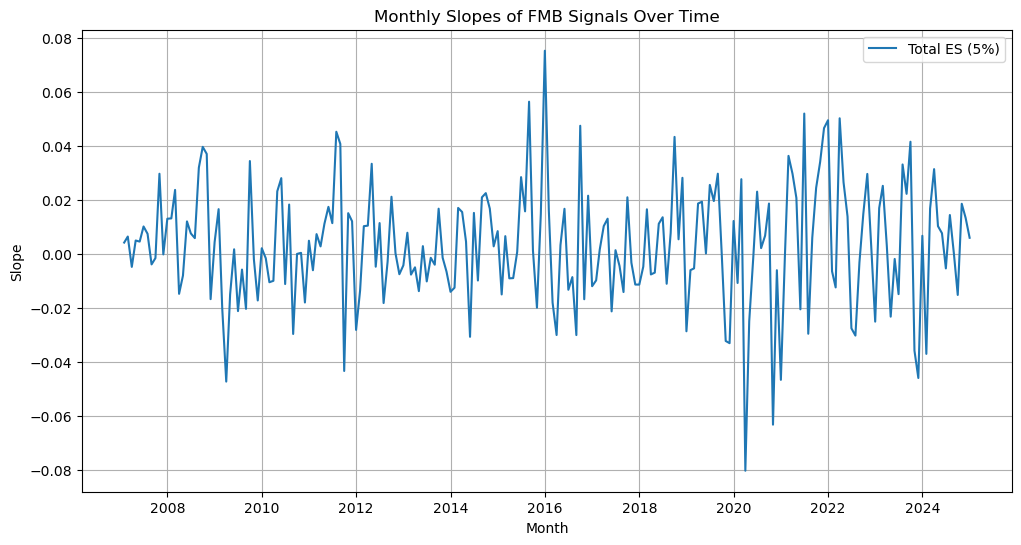

In [29]:

# draw the monthly slopes over time, each signal_name shows a line, x-axis is the month, y-axis is the slope
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
for signal_name in fmb_monthly_slopes['signal_name'].unique():
    signal_data = fmb_monthly_slopes[fmb_monthly_slopes['signal_name'] == signal_name]
    plt.plot(signal_data['mthcaldt'], signal_data['signal_slope'], label=signal_name)
plt.xlabel('Month')
plt.ylabel('Slope')
plt.title('Monthly Slopes of FMB Signals Over Time')
plt.legend()
plt.grid()
plt.show()

# Predictor Details

In [30]:
macro_details = pd.read_excel(PROJECT_ROOT / "data/PaperTable.xlsx", sheet_name="macro")
macro_details = macro_details.rename(columns={"Description (Detailed)": "Description"})
macro_details["Source"] = macro_details["Source"].replace({"Michael W. McCracken": "FRED-MD"})
formatted_factor_table = export_latex_table(
    macro_details,
    "macro_details.tex",
    "Macroeconomic and Financial Predictors",
    "tab:macro_details",
    (
        r"The table lists the macroeconomic and financial variables used by the forecasting models. FRED-MD variables follow \citet{mccrackenFredMD2016}. All series are aligned to the monthly forecast date before entering a rolling estimation window."
    ),
    landscape=False,
    font_size="scriptsize",
    column_format=r">{\raggedright\arraybackslash}p{0.18\textwidth}>{\raggedright\arraybackslash}p{0.20\textwidth}>{\raggedright\arraybackslash}p{0.52\textwidth}",
    table_position="H",
    arraystretch=1.08,
    use_adjustbox=False,
)
display(formatted_factor_table)

Saved: overleaf/tab_tex/macro_details.tex


,Variable,Source,Description
0,PAYEMS,FRED-MD,"All Employees, Total Nonfarm (Nonfarm Payrolls)"
1,UNRATE,FRED-MD,Unemployment Rate
2,INDPRO,FRED-MD,Industrial Production: Total Index
3,RPI,FRED-MD,Real Personal Income
4,ISRATIOx,FRED-MD,Total Business: Inventories to Sales Ratio
5,HOUST,FRED-MD,Housing Starts: Total New Privately Owned Hous...
6,BUSLOANS,FRED-MD,"Commercial and Industrial Loans, All Commercia..."
7,CPIAUCSL,FRED-MD,Consumer Price Index for All Urban Consumers: ...
8,VIXCLS,FRED,CBOE Volatility Index (VIX)
9,TERM_SPREAD,FRED,Difference between 10-Year Treasury Yield (DGS...


In [31]:
firm_details = pd.read_excel(PROJECT_ROOT / "data/PaperTable.xlsx", sheet_name="firm")
firm_details = firm_details.rename(columns={"Description (For Academic Paper)": "Description"})
formatted_factor_table = export_latex_table(
    firm_details,
    "firm_details.tex",
    "Firm-Level Predictors",
    "tab:firm_details",
    (
        r"The table lists the firm-level predictors used by the forecasting models. Missing values are filled first with the monthly industry median and then, when necessary, with the monthly cross-sectional median. FF12 is represented by a learned six-dimensional industry embedding in the neural models."
    ),
    landscape=False,
    font_size="scriptsize",
    column_format=r">{\raggedright\arraybackslash}p{0.16\textwidth}>{\raggedright\arraybackslash}p{0.21\textwidth}>{\raggedright\arraybackslash}p{0.53\textwidth}",
    table_position="H",
    arraystretch=1.04,
    use_adjustbox=False,
)
display(formatted_factor_table)

Saved: overleaf/tab_tex/firm_details.tex


,Variable,Source,Description
0,mthret,CRSP,Monthly Stock Return
1,mthprc,CRSP,End-of-Month Stock Price
2,MOM12m,CRSP,12-Month Momentum (Cumulative return from mont...
3,mu_bench,CRSP,Rolling 12-Month Average Monthly Return (inclu...
4,sigma_bench,CRSP,Rolling 12-Month Standard Deviation of Monthly...
5,turnover,CRSP,Monthly Turnover Ratio (Monthly Trading Volume...
6,mthcap_log,CRSP,Natural Logarithm of Monthly Market Capitaliza...
7,bm,Compustat WRDS ratios,Book-to-Market Ratio
8,evm,Compustat WRDS ratios,Enterprise Value Multiple
9,ps,Compustat WRDS ratios,Price-to-Sales Ratio


# Structured K3 State-Dependent Pricing

In [32]:
# Main specification: global adverse-weight z-score with rolling-window FE.
# This table compares Total ES, adverse contribution, and adverse severity
# across the portfolio, Fama--MacBeth, and pooled interaction tests.
state_pricing_parts = []

for alpha in [0.05, 0.10]:
    suffix = str(int(alpha * 100))
    target_signals = [
        f"Total ES ({alpha * 100:g}%)",
        "Adverse contribution",
        "Adverse severity",
    ]

    hml = pd.read_parquet(
        RESULT_DIR / f"state_hml_continuous_{timestamp}_alpha{suffix}.parquet"
    )
    hml = hml[
        (hml["state_specification"] == "Global z-score + window FE")
        & hml["signal_name"].isin(target_signals)
    ].copy()
    hml["Test"] = hml["weighting"].map({
        "EW": "H--L portfolio (EW)",
        "VW": "H--L portfolio (VW)",
    })
    hml = hml.rename(columns={
        "annualized_coefficient_pct": "Estimate",
        "nw_t": "t-statistic",
    })

    fmb = pd.read_parquet(
        RESULT_DIR / f"state_slope_regression_{timestamp}_alpha{suffix}.parquet"
    )
    fmb = fmb[
        (fmb["state_specification"] == "Global z-score + window FE")
        & fmb["signal_name"].isin(target_signals)
    ].copy()
    fmb["Test"] = "Fama--MacBeth slope"
    fmb = fmb.rename(columns={
        "annualized_coefficient_pct": "Estimate",
        "nw_t": "t-statistic",
    })

    pooled = pd.read_parquet(
        RESULT_DIR / f"pooled_interactions_{timestamp}_alpha{suffix}.parquet"
    )
    pooled = pooled[
        (pooled["state_specification"] == "Global z-score + window FE")
        & (pooled["cluster_type"] == "Month + firm")
        & (pooled["parameter"] == "interaction")
        & pooled["signal_name"].isin(target_signals)
    ].copy()
    pooled["Test"] = "Pooled interaction"
    pooled = pooled.rename(columns={
        "annualized_coefficient_pct": "Estimate",
        "cluster_t": "t-statistic",
    })

    combined = pd.concat([hml, fmb, pooled], ignore_index=True)
    combined["Signal"] = combined["signal_name"].where(
        ~combined["signal_name"].str.startswith("Total ES"),
        "Total ES",
    )
    combined["alpha"] = alpha
    state_pricing_parts.append(
        combined[["Test", "Signal", "alpha", "Estimate", "t-statistic"]]
    )

state_pricing_long = pd.concat(state_pricing_parts, ignore_index=True)
test_order = [
    "H--L portfolio (EW)",
    "H--L portfolio (VW)",
    "Fama--MacBeth slope",
    "Pooled interaction",
]
signal_order = ["Total ES", "Adverse contribution", "Adverse severity"]

table_rows = []
for test_name in test_order:
    for signal_name in signal_order:
        row = {"Test": test_name, "Signal": signal_name}
        for alpha, alpha_label in [(0.05, "5%"), (0.10, "10%")]:
            result = state_pricing_long[
                (state_pricing_long["Test"] == test_name)
                & (state_pricing_long["Signal"] == signal_name)
                & (state_pricing_long["alpha"] == alpha)
            ]
            if len(result) != 1:
                raise ValueError(
                    f"Expected one result for {test_name}, {signal_name}, {alpha_label}"
                )
            row[f"{alpha_label} estimate"] = result["Estimate"].iloc[0]
            row[f"{alpha_label} t-stat"] = result["t-statistic"].iloc[0]
        table_rows.append(row)

state_pricing_table = pd.DataFrame(table_rows)
formatted_state_pricing = export_latex_table(
    state_pricing_table,
    "17_adverse_state_pricing.tex",
    "State-Dependent Pricing of Structured K3 Tail Signals",
    "tab:adverse_state_pricing",
    (
        r"The table reports the annualized change in each return spread or signal slope, in percentage points, when the global adverse-component weight rises by one full-sample standard deviation. Portfolio and Fama--MacBeth state regressions include rolling-window fixed effects; the pooled regression includes window-specific signal slopes. H--L is the return on the highest-signal decile minus the return on the lowest-signal decile; EW and VW denote equal and value weighting. The Fama--MacBeth estimates come from second-stage regressions of monthly signal slopes controlling for log market capitalization, book-to-market equity, and twelve-month momentum on the adverse weight. Pooled estimates are coefficients on the signal-by-adverse-weight interaction, with month fixed effects, the same three controls, window-specific signal slopes, and standard errors clustered by month and firm. The portfolio and Fama--MacBeth tests use Newey--West standard errors with 12 lags. Firm-level signals and controls are winsorized at the monthly 1st and 99th percentiles and standardized within month where applicable. Because ES, contribution, and severity are expressed in signed return units, higher values represent less severe predicted losses."
    ),
    formats={
        "5% estimate": ".3f",
        "5% t-stat": ".2f",
        "10% estimate": ".3f",
        "10% t-stat": ".2f",
    },
    font_size="scriptsize",
    column_format="llrrrr",
    arraystretch=1.05,
)
display(formatted_state_pricing)

Saved: overleaf/tab_tex/17_adverse_state_pricing.tex


,Test,Signal,5% estimate,5% t-stat,10% estimate,10% t-stat
0,H--L portfolio (EW),Total ES,12.311,1.88,12.121,1.86
1,H--L portfolio (EW),Adverse contribution,20.523,2.81,18.658,2.78
2,H--L portfolio (EW),Adverse severity,13.803,2.14,14.033,2.22
3,H--L portfolio (VW),Total ES,10.968,1.33,11.706,1.47
4,H--L portfolio (VW),Adverse contribution,14.686,1.84,15.122,2.08
5,H--L portfolio (VW),Adverse severity,13.047,1.63,14.037,1.82
6,Fama--MacBeth slope,Total ES,2.353,1.37,2.409,1.43
7,Fama--MacBeth slope,Adverse contribution,4.612,2.32,4.014,2.14
8,Fama--MacBeth slope,Adverse severity,2.926,1.68,3.046,1.74
9,Pooled interaction,Total ES,3.336,1.55,3.330,1.53
